In [3]:
import sys 
import os 
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from fitting import sigmoid
from analysis_of_simulation_result import * 
import matplotlib.pyplot as plt
from make_network import *
sez_ids = np.concatenate(list(sez.values()))
sez_id2g = {f:g for g,fid in sez.items() for f in fid}

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 10



In [14]:
cell2color = pickle.load(open('assigned_color.pkl','rb'))

In [20]:
fitting_result_path = Path(REPO_ROOT/'figure4/figure4F-K.MN9_PER_fitting')
params_opt_tarsal = pickle.load(open(fitting_result_path/'fitting_result/tarsal/result_av1a1_170.pkl','rb'))
params_opt_labial = pickle.load(open(fitting_result_path/'fitting_result/labial/result_av1a1_170.pkl','rb'))
V_l1l2,K_l1l2,n_l1l2,V_l3,K_l3,n_l3,k_act_L,r0_L,h_L = params_opt_labial.x
V_at,K_at,n_at,V_tp,K_tp,n_tp,k_act_T,r0_T,h_T = params_opt_tarsal.x
popt_tarsal = [k_act_T,r0_T,h_T]
popt_labial = [k_act_L,r0_L,h_L]


data_df_labial = pd.read_parquet(REPO_ROOT/'figure7/figure7M-N.Screening_result_movable_vs_immobilized/simulation_data/simulation_data_labial.parquet')
data_df_tarsal = pd.read_parquet(REPO_ROOT/'figure7/figure7M-N.Screening_result_movable_vs_immobilized/simulation_data/simulation_data_tarsal.parquet')


,simul:sugar,simul:sugar+geosmin
FMIn,20.095,16.165
G2N-1,16.555,10.725
TH-VUM,18.645,14.190
bract,17.985,12.395
clavicle,18.090,12.485
meteor,19.165,14.070
rattle,18.510,12.465
roundup,2.885,1.125
usnea,20.105,14.685


In [16]:
def prepare_dataset(
    excel_path,
    data_df,
    control_values=None,
    rename_dict=None,
    drop_outliers=None,
    sheet_name=0,   # 추가
):

    # Load experimental data
    df = pd.read_excel(
        excel_path,
        index_col=0,
        sheet_name=sheet_name
    )

    lines = df.index.values.astype(str)

    # Mean per genotype
    df_mean = pd.DataFrame(columns=['exp:sugar', 'exp:sugar+geosmin'])

    for g in np.unique(lines):
        df_mean.loc[g] = [
            np.mean(df[lines == g]['exp:sugar'].values),
            np.mean(df[lines == g]['exp:sugar+geosmin'].values)
        ]

    # Rename indices
    if rename_dict is not None:
        df_mean.rename(index=rename_dict, inplace=True)

    # Add control
    if control_values is not None:
        control_sugar, control_geosmin = control_values
        df_mean.loc['control'] = [control_sugar, control_geosmin]

    # Merge simulation + experimental
    i1 = data_df.index.values
    i2 = df_mean.index.values

    all_df = pd.DataFrame(
        columns=[
            'simul:sugar',
            'simul:sugar+geosmin',
            'exp:sugar',
            'exp:sugar+geosmin'
        ]
    )

    for i in np.intersect1d(i1, i2):
        all_df.loc[i] = np.concatenate([
            data_df.loc[i].values,
            df_mean.loc[i].values
        ])

    # Remove outliers
    if drop_outliers is None:
        drop_outliers = []

    all_df_rm_outlier = all_df.drop(drop_outliers)

    # Flatten data
    x_data = np.concatenate([
        all_df_rm_outlier['simul:sugar'].values,
        all_df_rm_outlier['simul:sugar+geosmin'].values
    ])

    y_data = np.concatenate([
        all_df_rm_outlier['exp:sugar'].values,
        all_df_rm_outlier['exp:sugar+geosmin'].values
    ])

    return all_df, all_df_rm_outlier, x_data, y_data

In [17]:
from scipy.stats import linregress
def plot_screening_split_condition(
    df,
    popt,
    exp_scale,
    fit_scale,
    condition='sugar',   
    target=('FMIn', 'meteor'),
    label_condition=None,
    cell2color=None,
    marker='o',
    ax= None,
    fontsize=10,
    ps=25,
    lw=0.5):
    
    import numpy as np
    import matplotlib.pyplot as plt
    import distinctipy

    if cell2color is None:
        import distinctipy
        colors = distinctipy.get_colors(len(cells))
        cell2color = dict(zip(cells, colors))
        
    cells = df.index.values   # 🔥 이 줄 추가

    order_idx = np.arange(len(cells))
    target_idx = np.where(np.isin(cells, target))[0]

    wanted_order = np.concatenate([
        order_idx[~np.isin(order_idx, target_idx)],
        target_idx
    ])
    # 🔥 condition별 데이터 선택
    if condition == 'sugar':
        x_data = sigmoid(df['simul:sugar'].values,*popt)
        y_data = df['exp:sugar'].values
    elif condition == 'sugar+geosmin':
        x_data = sigmoid(df['simul:sugar+geosmin'].values,*popt)
        y_data = df['exp:sugar+geosmin'].values
    else:
        raise ValueError("condition must be 'sugar' or 'sugar+geosmin'")


    for i in wanted_order:
        this_cell = cells[i]

        # label 여부
        if label_condition is None:
            show_label = True
        else:
            show_label = label_condition(x_data, y_data, i)

        marker = marker#'o' if this_cell in target else 'o'

        kwargs = dict(
            color=cell2color[this_cell],
            s=ps,
            linewidths=lw,
            marker=marker,
            edgecolor='black'
        )

        if show_label:
            kwargs['label'] = this_cell

        ax.scatter(x_data[i], y_data[i], **kwargs)


    all_data = np.concatenate([x_data, y_data])
    data_min = np.nanmin(all_data)
    data_max = np.nanmax(all_data)
    
    margin = (data_max - data_min) * 0.05
    limit_range = np.arange(0,1.1,.1)#[data_min - margin, data_max + margin]
        
    mask = ~np.isnan(x_data) & ~np.isnan(y_data)
    x_clean, y_clean = x_data[mask], y_data[mask]
    
    ax.spines[['top', 'right']].set_visible(False)

    return {
        'cells': cells,
        'x': x_data,
        'y': y_data,
        'condition': condition
    }


def plot_regression_line(res,ax):
    
    x_target = res['x']
    y_target = res['y']


    slope_all, intercept_all, r_all, p_all, _ = linregress(x_target, y_target)
    
    xfit = np.linspace(np.nanmin(x_target), np.nanmax(x_target), 100)
    yfit_all = slope_all * xfit + intercept_all
    
    ax.plot(
        xfit, yfit_all,
        linestyle='--', color='gray', alpha=0.6,
        linewidth=1.5, zorder=1, label=f'All (r={r_all:.2f})'
    )

    stats_text = f'r= {r_all:.3f}'

    return r_all

def plot_identity_error(res, ax,plot=False):
    import numpy as np
    import pandas as pd

    x_target = np.asarray(res['x'])
    y_target = np.asarray(res['y'])

    # 
    valid = ~(np.isnan(x_target) | np.isnan(y_target))
    x_target = x_target[valid]
    y_target = y_target[valid]
    valid_cells = res['cells'][valid]  # 유효한 cell 이름 매칭용


    vertical_error = y_target - x_target

    #
    # 
    orthogonal_error = vertical_error / np.sqrt(2)
    abs_orthogonal_error = np.abs(orthogonal_error)
    sq_orthogonal_error = orthogonal_error**2
    
    # 
    rmse_orthogonal = np.sqrt(np.mean(sq_orthogonal_error))
    
    # 3. Identity line (y=x) 
    lim_max = max(np.max(x_target), np.max(y_target))
    
    if plot == True:
        ax.plot(
            [0, lim_max],
            [0, lim_max],
            linestyle='--',
            color='gray',
            alpha=0.6,
            linewidth=1.5,
            zorder=1,
            label=f'y=x (Geo_RMSE={rmse_orthogonal:.2f})'
        )

    error_df = pd.DataFrame({
        'x': x_target,
        'y': y_target,
        'vertical_error': vertical_error,            #
        'orthogonal_error': orthogonal_error,        #
        'abs_orthogonal_error': abs_orthogonal_error, # 
        'sq_orthogonal_error': sq_orthogonal_error    # 
    })

    error_df.index = valid_cells
    error_df.index.name = 'neuron'

    return rmse_orthogonal, error_df


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

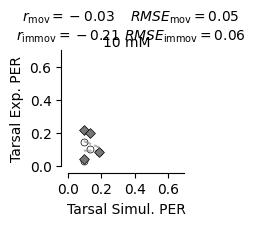

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

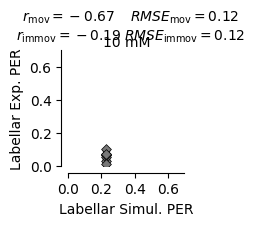

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

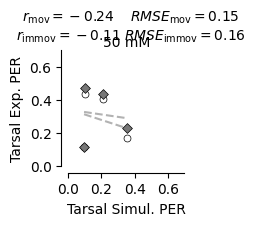

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

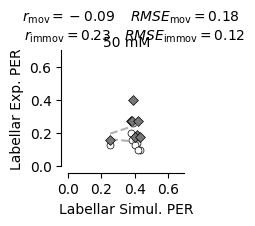

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

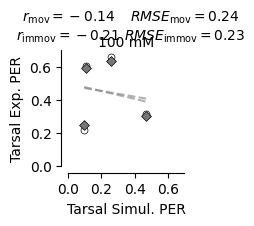

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

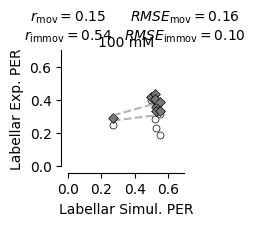

In [21]:
concentrations = [10, 50, 100]

rename_dict = {
    'FMin': 'FMIn',
    'meteor': 'meteor',
    'sink,sync': 'sink and sync'
}

popt = {
    'tarsal': popt_tarsal,
    'labial': popt_labial
}

for conc in concentrations:
    data_df_tarsal = pd.read_parquet(f'simulation_data/simulation_data_tarsal-{conc}mM.parquet')
    data_df_labial = pd.read_parquet(f'simulation_data/simulation_data_labial-{conc}mM.parquet')
    # =====================================
    # prepare data for each concentration
    # =====================================

    all_df = {}
    all_df_fixed = {}

    # ---------- tarsal ----------
    all_df_tarsal, _, _, _ = prepare_dataset(
        excel_path=f'data_fixed/tarsal_{conc}mM.xlsx',
        sheet_name='non_fixed',
        data_df=data_df_tarsal,
        rename_dict=rename_dict,
        drop_outliers=[]
    )

    all_df_tarsal_fixed, _, _, _ = prepare_dataset(
        excel_path=f'data_fixed/tarsal_{conc}mM.xlsx',
        sheet_name='fixed',
        data_df=data_df_tarsal,
        rename_dict=rename_dict,
        drop_outliers=[]
    )


    # ---------- labial ----------
    all_df_labial, _, _, _ = prepare_dataset(
        excel_path=f'data_fixed/labial_{conc}mM.xlsx',
        sheet_name='non_fixed',
        data_df=data_df_labial,
        rename_dict=rename_dict,
        drop_outliers=[]
    )

    all_df_labial_fixed, _, _, _ = prepare_dataset(
        excel_path=f'data_fixed/labial_{conc}mM.xlsx',
        sheet_name='fixed',
        data_df=data_df_labial,
        rename_dict=rename_dict,
        drop_outliers=[]
    )


    all_df['tarsal'] = all_df_tarsal.drop(['meteor','control'], errors='ignore')
    all_df['labial'] = all_df_labial.drop(['meteor','control'], errors='ignore')

    all_df_fixed['tarsal'] = all_df_tarsal_fixed.drop(
        'meteor',
        errors='ignore'
    )

    all_df_fixed['labial'] = all_df_labial_fixed.drop(
        'meteor',
        errors='ignore'
    )


    # =====================================
    # plot: one site = one figure
    # =====================================

    for site in ['tarsal', 'labial']:

        cond = 'sugar'

        fig, ax = plt.subplots(
            1,
            1,
            figsize=(1.5, 1.5)
        )


        # =====================================
        # movable / non-fixed
        # =====================================

        res = plot_screening_split_condition(
            all_df[site],
            popt[site],
            exp_scale=None,
            fit_scale=None,
            ax=ax,
            condition=cond,
            cell2color={
                x: '#ffffff'
                for x in cell2color.keys()
            },
            marker='o'
        )

        r1 = plot_regression_line(
            res,
            ax
        )

        rmse1, error_df1 = plot_identity_error(
            res,
            ax
        )


        # =====================================
        # immovable / fixed
        # =====================================

        res = plot_screening_split_condition(
            all_df_fixed[site],
            popt[site],
            exp_scale=None,
            fit_scale=None,
            ax=ax,
            condition=cond,
            cell2color={
                x: '#777777'
                for x in cell2color.keys()
            },
            marker='D'
        )

        r2 = plot_regression_line(
            res,
            ax
        )

        rmse2, error_df2 = plot_identity_error(
            res,
            ax
        )


        # =====================================
        # text
        # =====================================

        text = (
            fr'$r_{{\mathrm{{mov}}}} = {r1:.2f}$'
            + '\n'
            + fr'$r_{{\mathrm{{immov}}}} = {r2:.2f}$'
        )

        text2 = (
            fr'$RMSE_{{\mathrm{{mov}}}} = {rmse1:.2f}$'
            + '\n'
            + fr'$RMSE_{{\mathrm{{immov}}}} = {rmse2:.2f}$'
        )

        ax.text(
            0,
            1.05,
            text,
            transform=ax.transAxes,
            ha='center',
            va='bottom',
            clip_on=False
        )

        ax.text(
            1,
            1.05,
            text2,
            transform=ax.transAxes,
            ha='center',
            va='bottom',
            clip_on=False
        )


        # =====================================
        # axis
        # =====================================

        ax.set_xticks(
            np.arange(0, 0.8, 0.2)
        )

        ax.set_yticks(
            np.arange(0, 0.8, 0.2)
        )

        ax.set_xlim(
            0,
            0.7
        )

        ax.set_ylim(
            0,
            0.7
        )


        site_label = (
            'Labellar'
            if site == 'labial'
            else 'Tarsal'
        )

        ax.set_ylabel(
            f'{site_label} Exp. PER'
        )

        ax.set_xlabel(
            f'{site_label} Simul. PER'
        )

        ax.set_title(
            f'{conc} mM',
            fontsize=10,
            pad=3
        )

        ax.spines['left'].set_position(
            ('outward', 5)
        )

        ax.spines['bottom'].set_position(
            ('outward', 5)
        )

        plt.show()

        # plt.savefig(
        #     f'{site}_{conc}mM_{cond}.svg',
        #     bbox_inches='tight'
        # )